## Clustering events, plot geographical and time distribution
Fig 3

In [3]:
# for everything else
import os
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import pandas as pd
import pickle
import glob
from matplotlib import rcParams
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cf


# clustering and dimension reduction
from sklearn.cluster import KMeans
# for loading/processing the images  
from keras.preprocessing.image import load_img

2026-08-11 13:17:31.600414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
rcParams['font.size'] = 20

In [5]:
exp = 'prect_6_clim'
exp_label = 'Precip 5day 6 sigma clim'

path = f"/div/nac/users/zofias/plots/XXN/{exp}/single"
# change the working directory to the path where the images are located
os.chdir(path)

# this list holds all the image filename
maps = glob.glob(f'*.png')

In [6]:
# load the processed data

#this is the data that looks like the 4000m 
#x = np.load(path+'imageclustering2000m_processed.npy')

#this is the data that is in portrait format
x = np.load(f"{path}/imageclustering_{exp}_single_processed_portrait.npy")

Text(0, 0.5, 'Sum of squared distance')

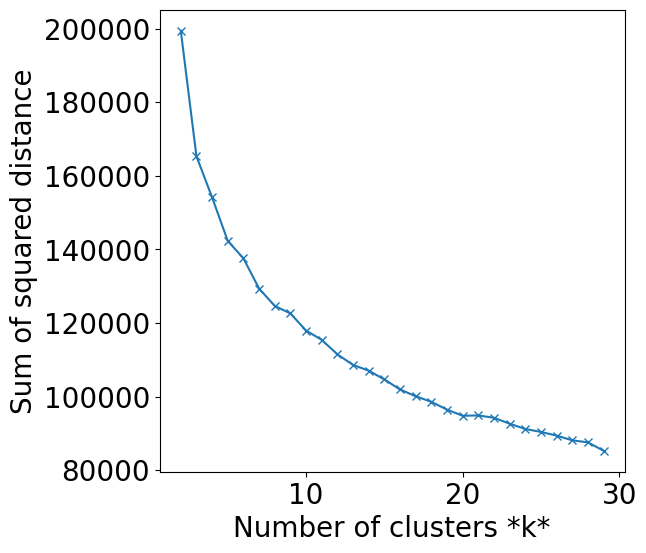

In [7]:
sse = []
list_k = list(range(2, 30))

for k in list_k:
    km = KMeans(n_clusters=k, random_state=7)
    km.fit(x)
   
    sse.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(6, 6))
plt.plot(list_k, sse, marker="x")
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')
#plt.ylim(0,)

In [8]:
#cluster groups and print number of event sin each group
kmeans = KMeans(n_clusters=7,random_state=7)
kmeans.fit(x)

# holds the cluster id and the images { id: [images] }
groups = {}
for file, cluster in zip(maps,kmeans.labels_):
    if cluster not in groups.keys():
        groups[cluster] = []
        groups[cluster].append(file)
    else:
        groups[cluster].append(file)
        
for i in range(len(groups)):
    print(len(groups[i]))

109
83
52
82
34
19
95


In [9]:
# function that lets you view a cluster (based on identifier)        
def view_cluster(cluster):
    plt.figure(figsize = (25,25));
    # gets the list of filenames for a cluster
    files = groups[cluster]
    # only allow up to 50 images to be shown at a time
    if len(files) > 50:
        print(f"Cluster {cluster+1}")
        print(f"Clipping cluster size from {len(files)} to 50")
        files = files[:49]
    # plot each image in the cluster
    for index, file in enumerate(files):
        plt.subplot(10,10,index+1);
        img = load_img(file)
        img = np.array(img)
        plt.imshow(img)
        plt.axis('off')

Cluster 1
Clipping cluster size from 109 to 50


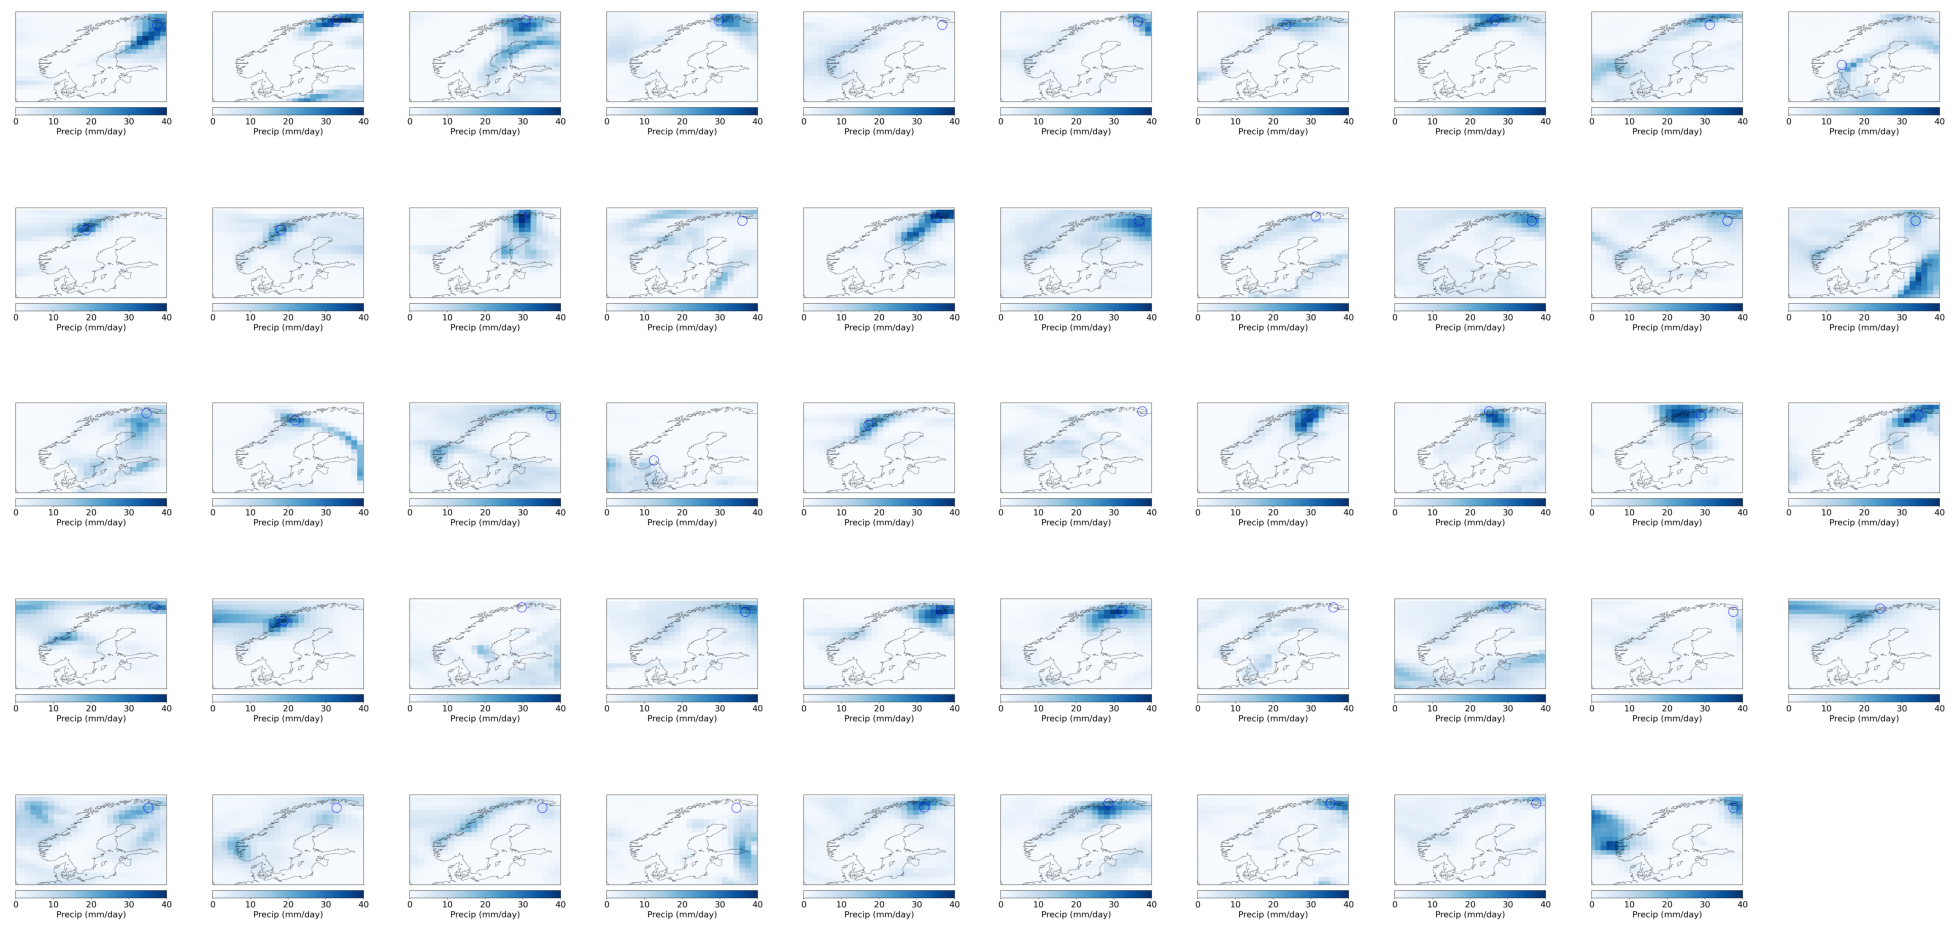

In [10]:
view_cluster(0)

Cluster 2
Clipping cluster size from 83 to 50


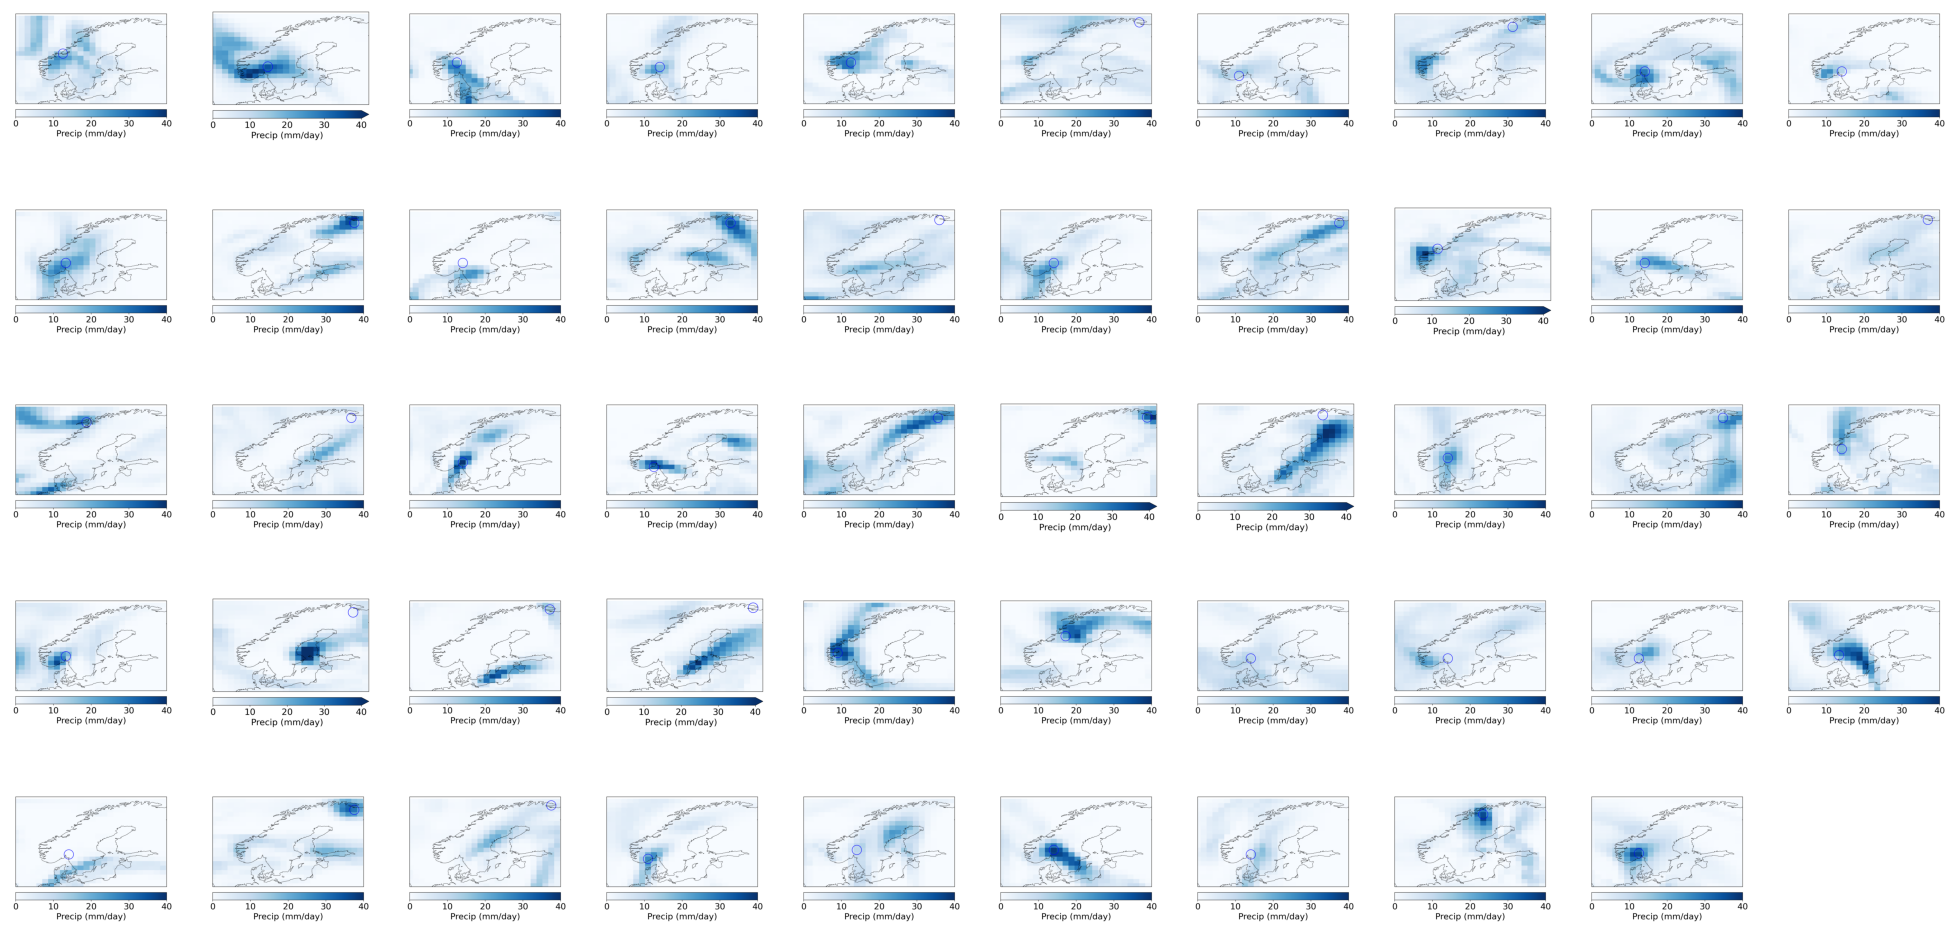

In [11]:
view_cluster(1)

Cluster 3
Clipping cluster size from 52 to 50


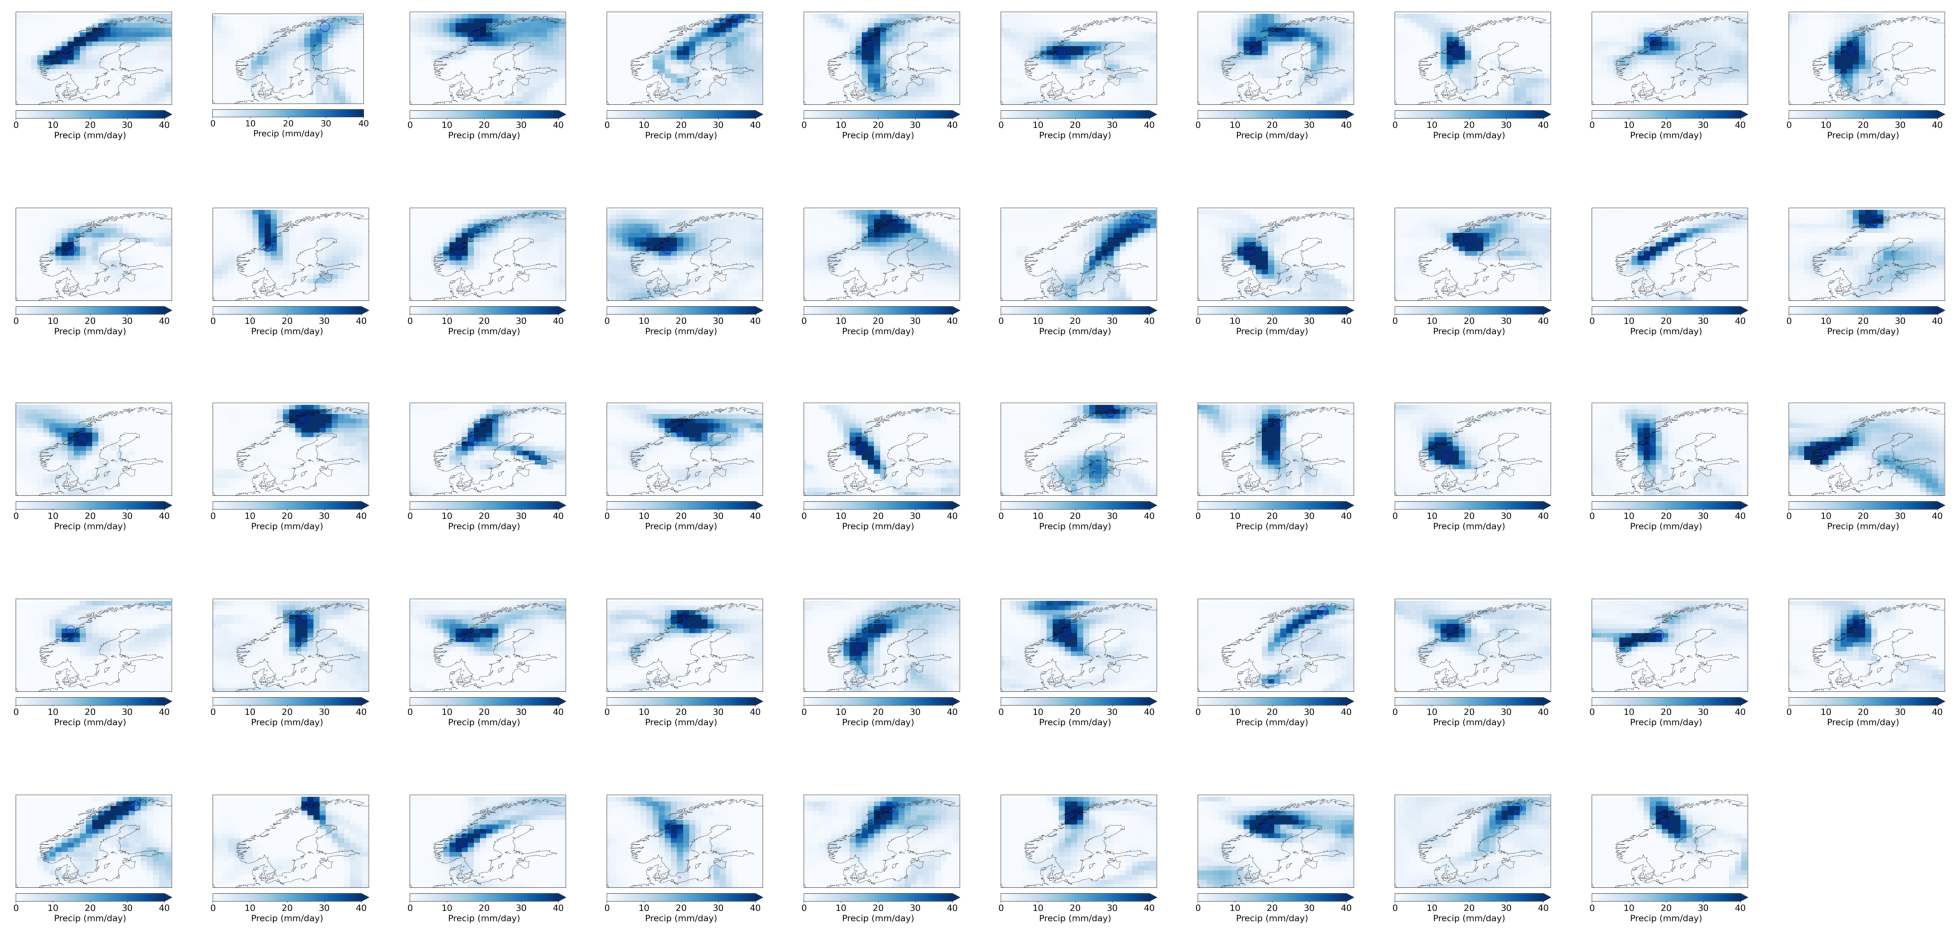

In [12]:
view_cluster(2)

Cluster 4
Clipping cluster size from 82 to 50


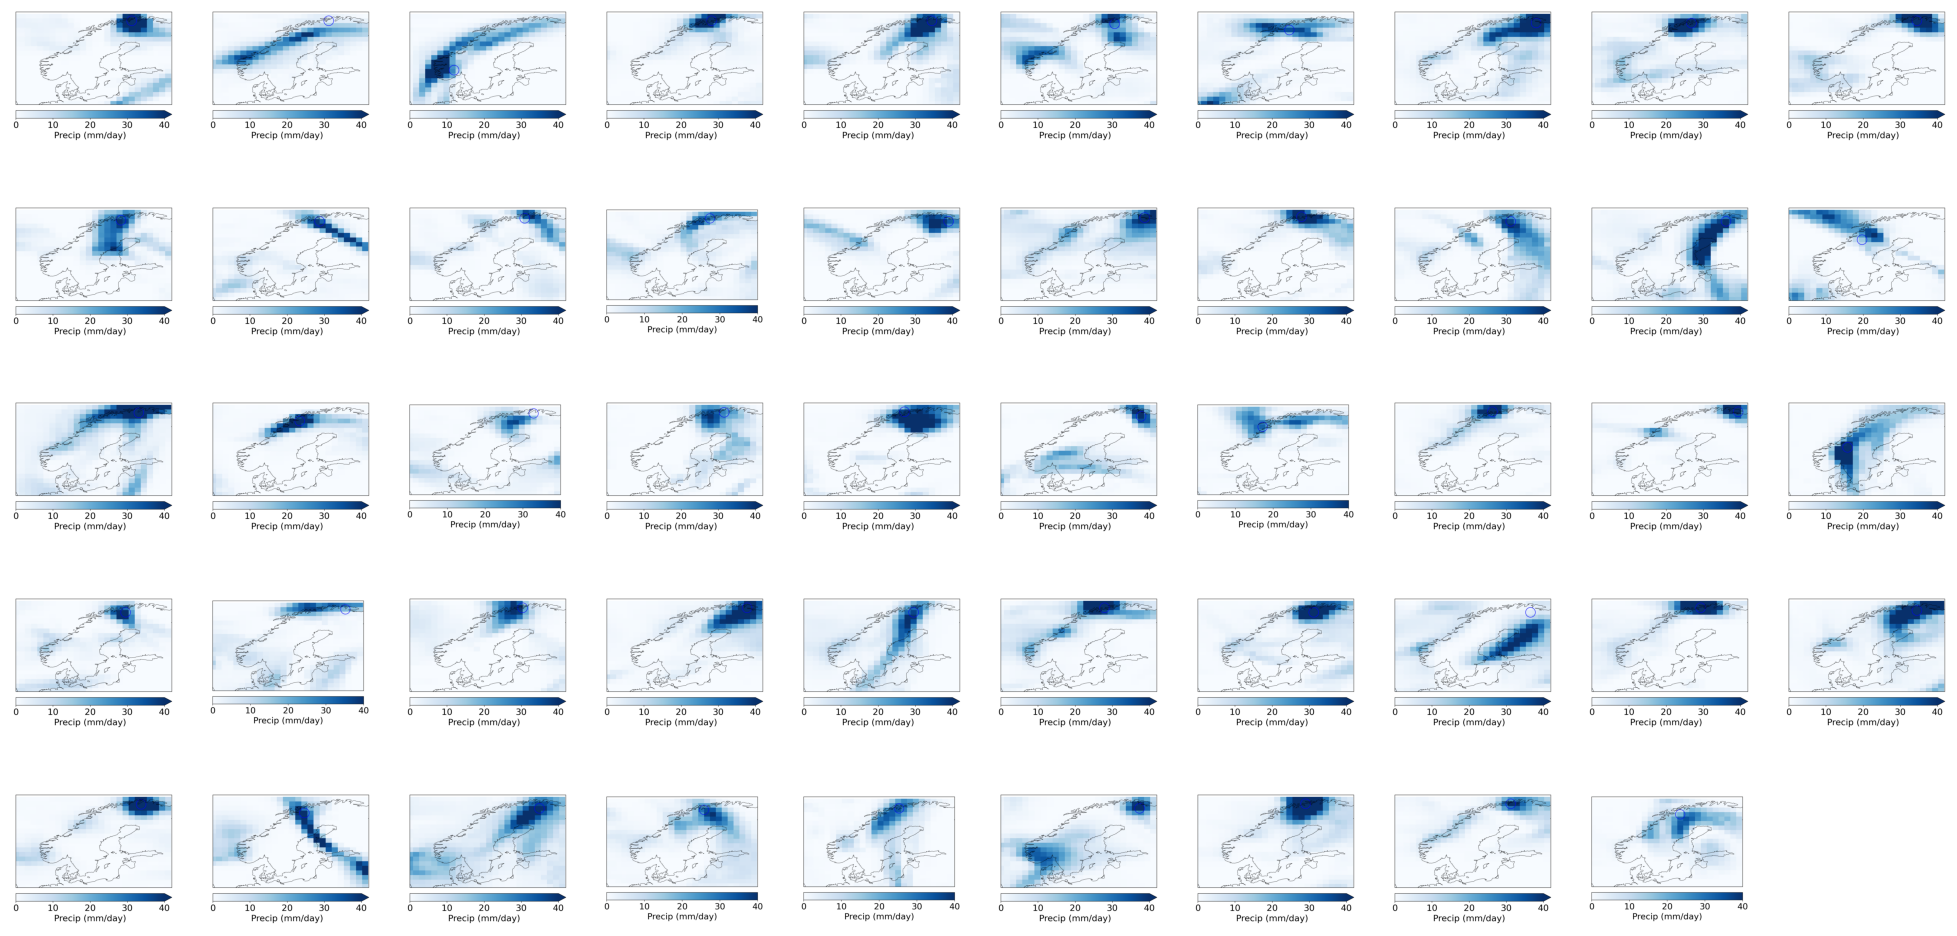

In [13]:
view_cluster(3)

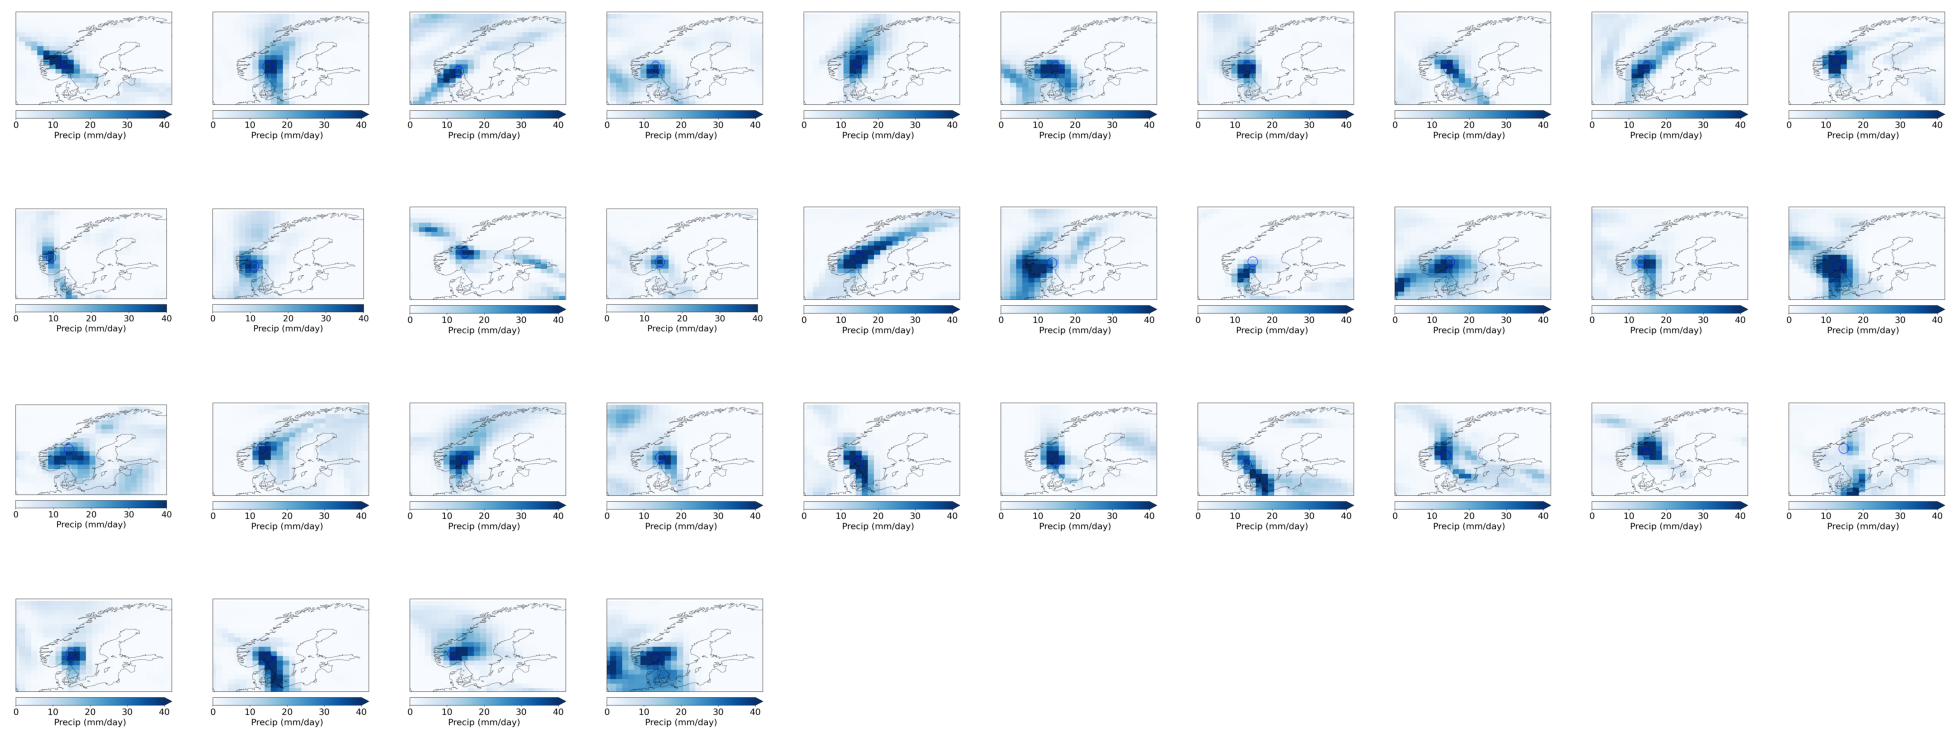

In [14]:
view_cluster(4)

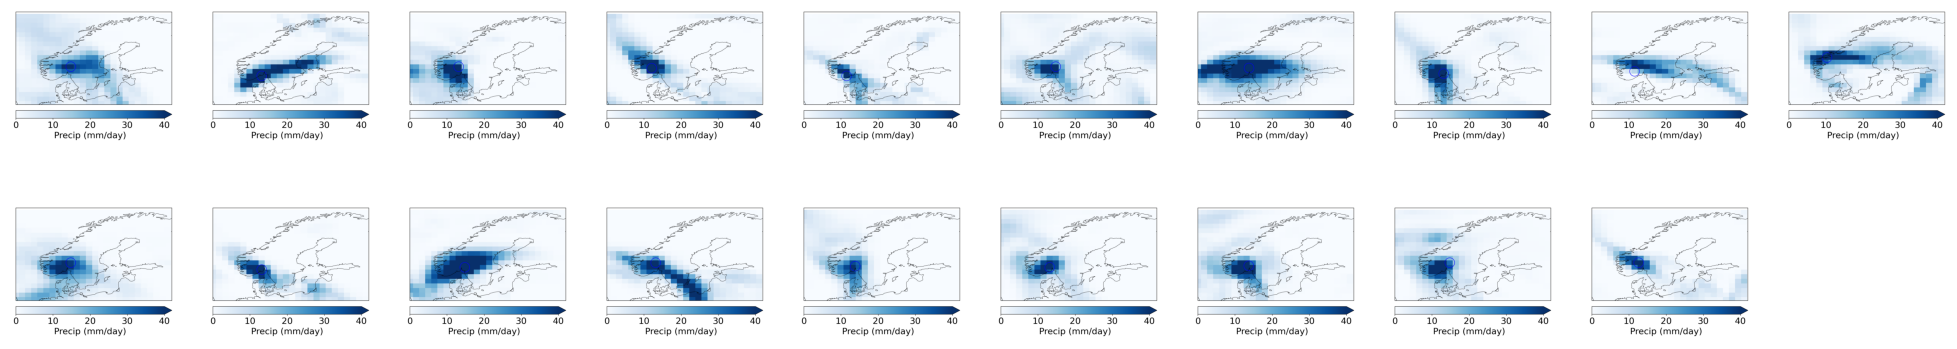

In [15]:
view_cluster(5)

## Make dataframe of groups

In [16]:
def convert_pandas_time(dataframe):
    dataframe['pd_time'] = pd.to_datetime(dataframe['date'], format='%Y-%m-%d',errors='coerce')

In [17]:
#for 14day temp
all_events_list = []

for i in range(len(groups)):
    group_temp_table = pd.DataFrame(groups[i],columns=['filename'])
    group_temp_table['date'] = group_temp_table.filename.str.split('_').str[3]
    group_temp_table['lat'] = group_temp_table.filename.str.split('_').str[4].astype(float)
    group_temp_table['lon'] = group_temp_table.filename.str.split('_').str[5].astype(float)
    group_temp_table['sigma'] = group_temp_table.filename.str.split('_').str[1]
    group_temp_table['ens_member'] = group_temp_table.filename.str.split('_').str[2]
    group_temp_table['type'] = group_temp_table.filename.str.split('_').str[0]
    group_temp_table['group'] = i
    all_events_list.append(group_temp_table)

In [18]:
#merge all into dataframe
all_events = pd.concat(all_events_list,ignore_index=True)
#convert to datetime
convert_pandas_time(all_events)

In [19]:
#make column for month and year
all_events['month'] = all_events['pd_time'].dt.month
all_events['year'] = all_events['pd_time'].dt.year

In [20]:
all_events

,filename,date,lat,lon,sigma,ens_member,type,group,pd_time,month,year
0,PRECT5day_6_r10_2093-09-04_69.27_30.0_single.png,2093-09-04,69.27,30.00,6,r10,PRECT5day,0,2093-09-04,9,2093
1,PRECT5day_6_r11_2079-06-30_70.21_26.25_single.png,2079-06-30,70.21,26.25,6,r11,PRECT5day,0,2079-06-30,6,2079
2,PRECT5day_6_r1_2072-06-15_70.21_24.58_single.png,2072-06-15,70.21,24.58,6,r1,PRECT5day,0,2072-06-15,6,2072
3,PRECT5day_6_r12_2044-06-15_70.21_23.75_single.png,2044-06-15,70.21,23.75,6,r12,PRECT5day,0,2044-06-15,6,2044
4,PRECT5day_6_r12_2050-10-05_69.27_29.38_single.png,2050-10-05,69.27,29.38,6,r12,PRECT5day,0,2050-10-05,10,2050
...,...,...,...,...,...,...,...,...,...,...,...
469,PRECT5day_6_r6_2095-10-05_70.21_30.0_single.png,2095-10-05,70.21,30.00,6,r6,PRECT5day,6,2095-10-05,10,2095
470,PRECT5day_6_r7_2073-07-10_69.87_26.76_single.png,2073-07-10,69.87,26.76,6,r7,PRECT5day,6,2073-07-10,7,2073
471,PRECT5day_6_r8_2028-09-08_69.27_30.0_single.png,2028-09-08,69.27,30.00,6,r8,PRECT5day,6,2028-09-08,9,2028
472,PRECT5day_6_r8_2082-11-01_69.27_25.31_single.png,2082-11-01,69.27,25.31,6,r8,PRECT5day,6,2082-11-01,11,2082


In [21]:
all_events.to_csv(f'{path}/grouped_events_table.csv')

## Plot different clusters, spatial and temporal distribution

In [22]:
month_labs = ['J','F','M','A','M','J','J','A','S','O','N','D']
cmap_dark2 = mpl.colormaps['Dark2']

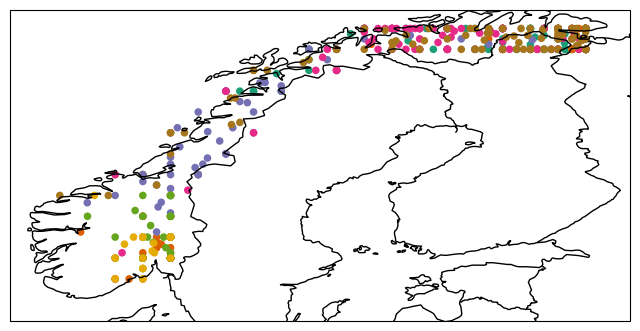

In [23]:
#plot all on one map
plt.figure(figsize = (8,10),dpi =100)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines(resolution='50m')
ax.add_feature(cf.BORDERS)
ax.set_extent([4,32,57,71,])


plt.scatter(all_events['lon'],all_events['lat'],marker='o',s = 30,edgecolors='none',
            transform = ccrs.PlateCarree(),
            c = all_events['group'],cmap='Dark2',vmax=8)

plt.show()

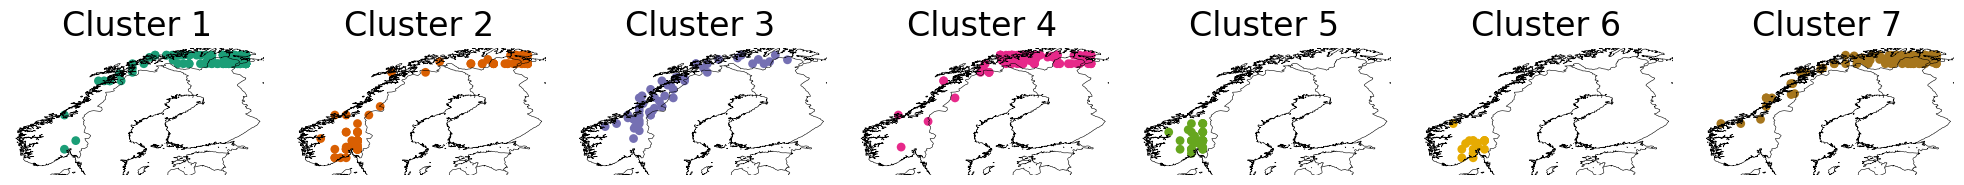

In [24]:
fig, axs = plt.subplots(nrows=1,ncols=len(groups),
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(20,5),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    axs[n].coastlines(linewidth=0.4)  # cartopy function
    axs[n].scatter(select_group['lon'],select_group['lat'],marker='o',s = 40,alpha=1,edgecolors='none',
            transform = ccrs.PlateCarree(),
            c = select_group['group'],cmap='Dark2',vmax=8,vmin=0,
            )
    
    #axs[n].coastlines(linewidth=0.2)  # cartopy function
    axs[n].add_feature(cf.BORDERS,linewidth=0.4)
    axs[n].set_extent([4,32,57,71,])
    axs[n].set_title(f'Cluster {n+1}',y=1.03)
    axs[n].spines[['right', 'left','top']].set_visible(False)

#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=1)

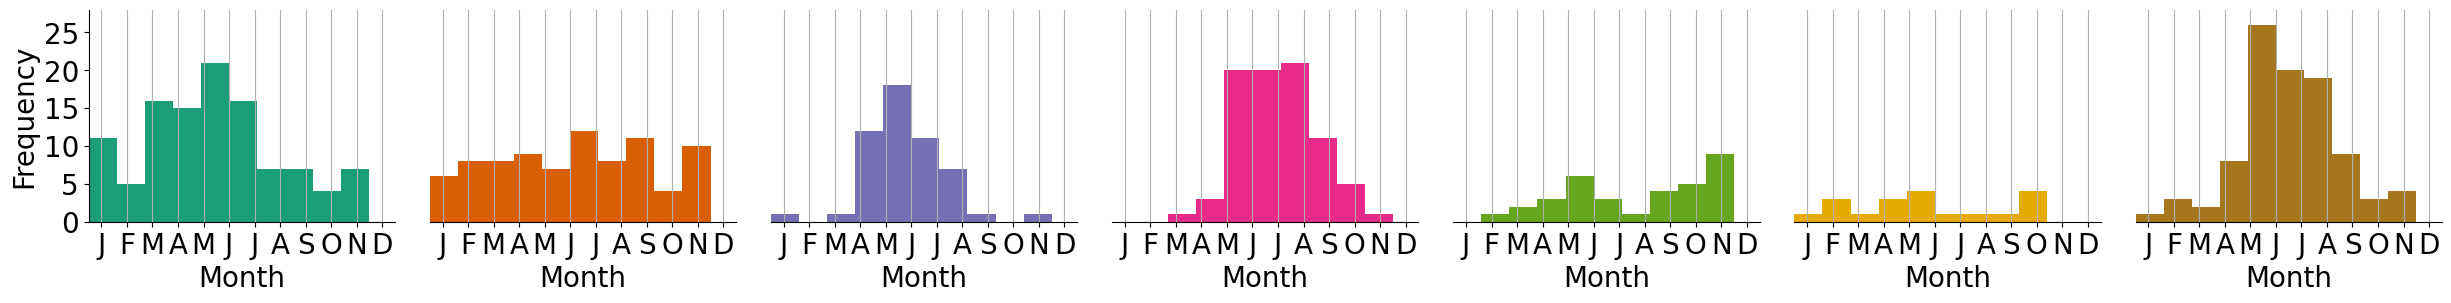

In [25]:
fig, axs = plt.subplots(nrows=1,ncols=len(groups),
                        subplot_kw={},
                        #sharey='row',
                        figsize=(25,3.5)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    #bins = np.linspace(1, 12, 12)

    select_group.hist(column=['month'],ax=axs[n],range=[1,12],color=cmap_dark2(n/8))
    axs[n].set_xlabel('Month')
    axs[0].set_ylabel('Frequency')
    axs[n].set_title(f'') #Group {n+1}
    axs[n].set_xticks(np.arange(1.5,13))
    axs[n].set_xticklabels(month_labs)
    #axs[n].set_aspect(0.2)
    axs[n].set_xlim(1,13)
    axs[n].set_ylim(0,28)
    axs[n].spines[['left','right', 'top']].set_visible(False)
    axs[0].spines[['left']].set_visible(True)
    axs[n].set_yticks([])
    axs[0].set_yticks(np.arange(0,26,5).tolist())
    axs[n].grid(axis='y', visible=False)

plt.tight_layout(pad=1.2)

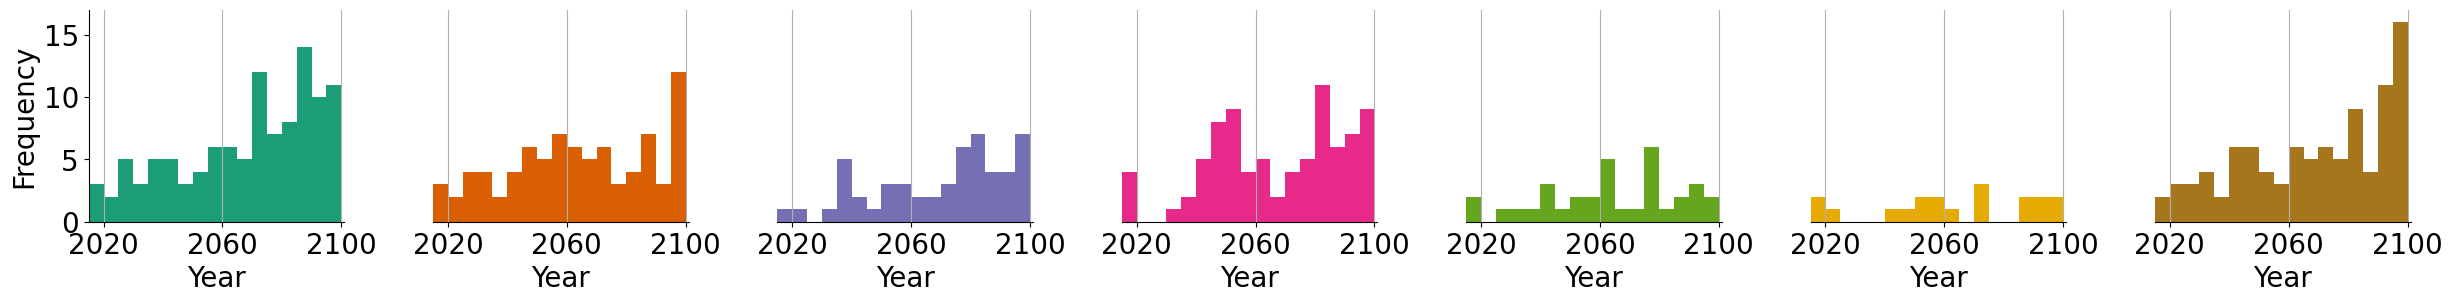

In [26]:
fig, axs = plt.subplots(nrows=1,ncols=len(groups),
                        #subplot_kw={'projection': ccrs.PlateCarree()},
                        #sharey='row',
                        figsize=(25,3.5)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    #bins = np.linspace(1, 12, 12)

    select_group.hist(column=['year'],bins=np.arange(2015,2101,5),ax=axs[n],color=cmap_dark2(n/8))
    axs[n].set_ylim(0,17)
    axs[n].set_xlabel('Year')
    axs[0].set_ylabel('Frequency')
    axs[n].set_title(f'')
    axs[n].set_xlim(2015,2101)
    axs[n].spines[['left','right', 'top']].set_visible(False)
    axs[0].spines[['left']].set_visible(True)
    axs[n].set_yticks([])
    axs[0].set_yticks(np.arange(0,16,5).tolist())
    axs[n].set_xticks(np.arange(2020,2101,40).tolist())
    axs[n].grid(axis='y', visible=False)

plt.tight_layout(pad=1.2)

### Vertical plots instead

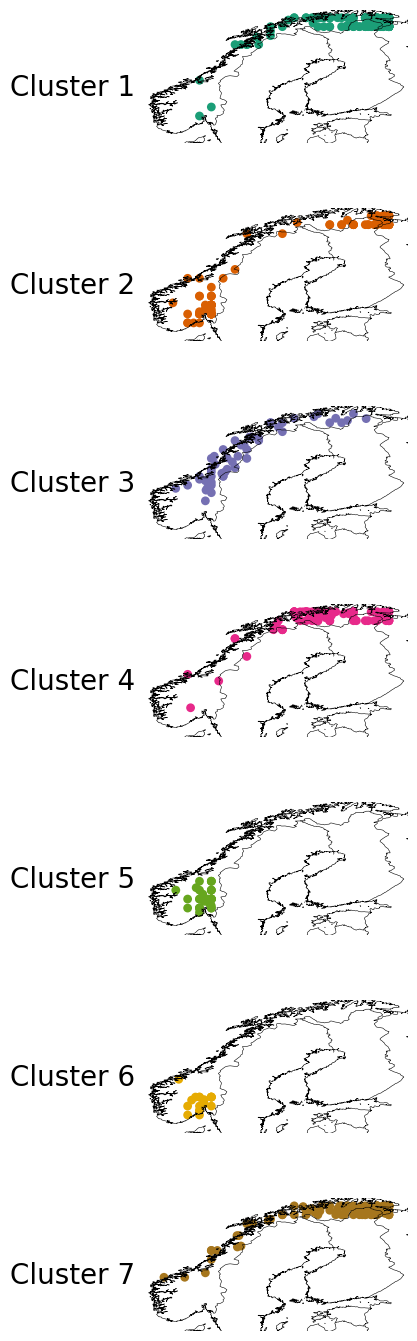

In [27]:
fig, axs = plt.subplots(nrows=len(groups),ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(4,14),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    axs[n].coastlines(linewidth=0.4)  # cartopy function
    axs[n].scatter(select_group['lon'],select_group['lat'],marker='o',s = 40,alpha=1,edgecolors='none',
            transform = ccrs.PlateCarree(),
            c = select_group['group'],cmap='Dark2',vmax=8,vmin=0,
            )
    
    #axs[n].coastlines(linewidth=0.2)  # cartopy function
    axs[n].add_feature(cf.BORDERS,linewidth=0.4)
    axs[n].set_extent([4,32,57,71,])
    axs[n].set_title('')#(f'Cluster {n+1}',y=1.03)
    axs[n].spines[['right', 'left','top']].set_visible(False)
    axs[n].text(-10, 62, f'Cluster {n+1}')

#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=0.5)

/scratch/tmp/ipykernel_2660720/3775562592.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(month_labs)
/scratch/tmp/ipykernel_2660720/3775562592.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(month_labs)
/scratch/tmp/ipykernel_2660720/3775562592.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(month_labs)
/scratch/tmp/ipykernel_2660720/3775562592.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels(month_labs)
/scratch/tmp/ipykernel_2660720/3775562592.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

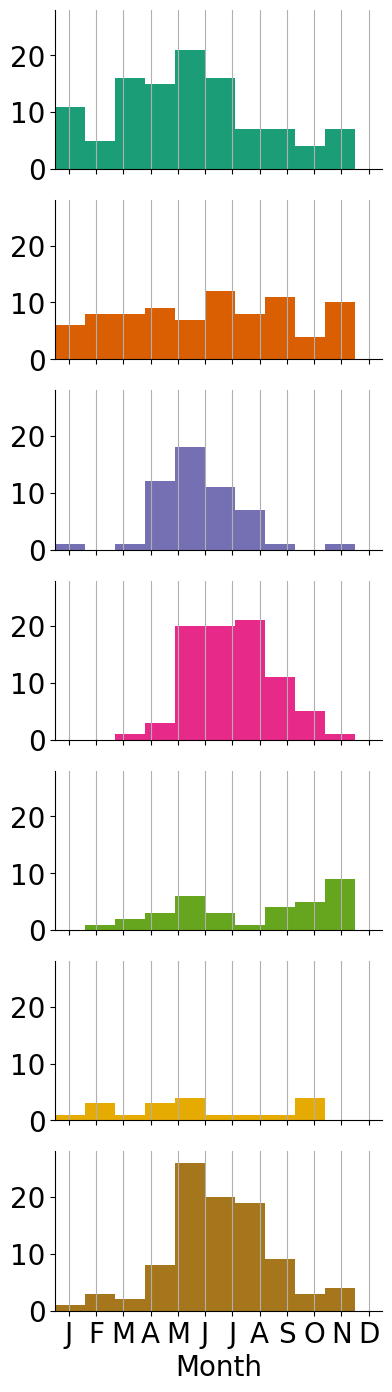

In [28]:
fig, axs = plt.subplots(nrows=len(groups),ncols=1,
                        subplot_kw={},
                        #sharey='row',
                        figsize=(4,14)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    #bins = np.linspace(1, 12, 12)

    select_group.hist(column=['month'],ax=axs[n],range=[1,12],color=cmap_dark2(n/8))
    #axs[n].set_xlabel('')
    axs[-1].set_xlabel('Month')
    #axs[0].set_ylabel('Frequency')
    axs[n].set_title(f'') #Group {n+1}
    axs[n].set_xticks(np.arange(1.5,13))
    axs[n].set_xticklabels([])
    axs[-1].set_xticklabels(month_labs)
    #axs[n].set_aspect(0.2)
    axs[n].set_xlim(1,13)
    axs[n].set_ylim(0,28)
    axs[n].spines[['left','right', 'top']].set_visible(False)
    axs[n].spines[['left']].set_visible(True)
    axs[n].set_yticks([])
    axs[n].set_yticks(np.arange(0,26,10).tolist())
    axs[n].grid(axis='y', visible=False)

plt.tight_layout(pad=0.5)

/scratch/tmp/ipykernel_2660720/153402380.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels([2015,2045,2075,2100])
/scratch/tmp/ipykernel_2660720/153402380.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels([2015,2045,2075,2100])
/scratch/tmp/ipykernel_2660720/153402380.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels([2015,2045,2075,2100])
/scratch/tmp/ipykernel_2660720/153402380.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[-1].set_xticklabels([2015,2045,2075,2100])
/scratch/tmp/ipykernel_2660720/153402380.py:26: UserWarning: set_ticklabels() should only be used wi

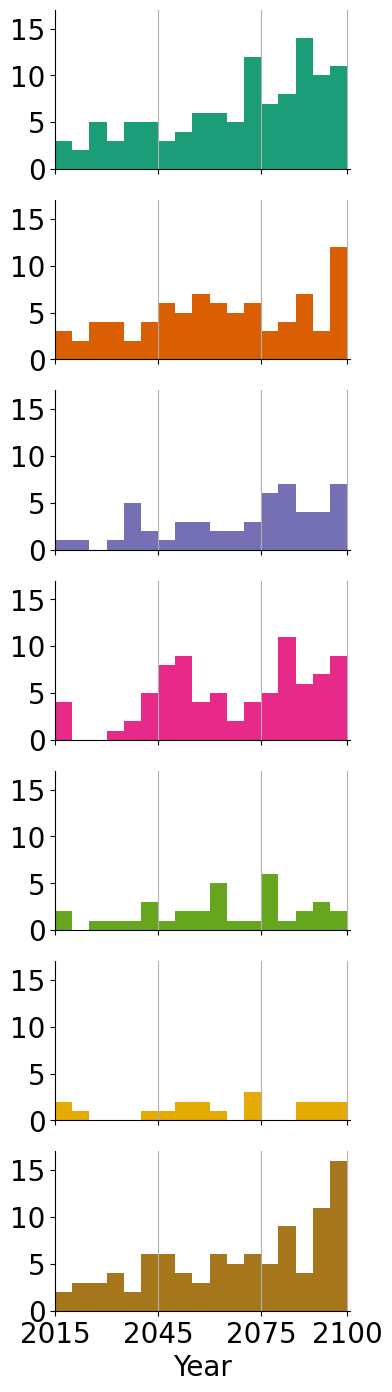

In [29]:
fig, axs = plt.subplots(nrows=len(groups),ncols=1,
                        #subplot_kw={'projection': ccrs.PlateCarree()},
                        #sharey='row',
                        figsize=(4,14)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,group in enumerate(groups):
    select_group = all_events[all_events["group"] == n]
    #bins = np.linspace(1, 12, 12)

    select_group.hist(column=['year'],ax=axs[n],bins=np.arange(2015,2101,5),color=cmap_dark2(n/8))
    axs[n].set_ylim(0,17)
    axs[-1].set_xlabel('Year')
    #axs[0].set_ylabel('Frequency')
    axs[n].set_title(f'')
    axs[n].set_xlim(2015,2101)
    axs[n].spines[['left','right', 'top']].set_visible(False)
    axs[n].spines[['left']].set_visible(True)
    axs[n].set_yticks(np.arange(0,16,5).tolist())
    axs[n].set_xticks([2015,2045,2075,2100])#np.arange(2020,2101,40).tolist())
    axs[n].set_xticklabels([])
    axs[-1].set_xticklabels([2015,2045,2075,2100])
    axs[n].grid(axis='y', visible=False)

plt.tight_layout(pad=0.5)

In [42]:
np.histogram(all_events[all_events["group"] == 6]['year'], bins=np.arange(2015,2101,5))

(array([ 2,  3,  3,  4,  2,  6,  6,  4,  3,  6,  5,  6,  5,  9,  4, 11, 16]),
 array([2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065,
        2070, 2075, 2080, 2085, 2090, 2095, 2100]))

In [31]:
select_group.hist(column=['year'],ax=axs[n],bins=np.arange(2015,2101,5),color=cmap_dark2(n/8))

array([<Axes: title={'center': 'year'}, xlabel='Year'>], dtype=object)